# Nuclear NPV simulation

Run the nuclear electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)


In [2]:
TECHNOLOGY = 'nuclear'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,nuclear,1000000.0,5300.0,188.679245,188679.245283,15724.587499,102.953740,6.987695,2.821163,...,94070000.0,1.942523e+07,6.987695e+06,2.256930e+07,0.0,4.508777e+07,-2.485601e+09,25000000.0,-99.424059,-0.000099
1,1,nuclear,1000000.0,5300.0,188.679245,188679.245283,15964.531102,97.379906,6.372797,2.987866,...,94070000.0,1.837357e+07,6.372797e+06,2.390292e+07,0.0,4.542071e+07,-2.527320e+09,25000000.0,-101.092790,-0.000101
2,2,nuclear,1000000.0,5300.0,188.679245,188679.245283,7427.021501,101.561229,6.895060,2.801533,...,94070000.0,1.916250e+07,6.895060e+06,2.241226e+07,0.0,4.560018e+07,-9.145531e+08,25000000.0,-36.582124,-0.000037
3,3,nuclear,1000000.0,5300.0,188.679245,188679.245283,6065.722358,97.025903,8.171383,2.765593,...,94070000.0,1.830677e+07,8.171383e+06,2.212474e+07,0.0,4.546710e+07,-6.591248e+08,25000000.0,-26.364992,-0.000026
4,4,nuclear,1000000.0,5300.0,188.679245,188679.245283,9114.025618,116.206434,7.746482,2.892678,...,94070000.0,2.192574e+07,7.746482e+06,2.314142e+07,0.0,4.125635e+07,-1.279225e+09,25000000.0,-51.169006,-0.000051


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-1602.014152,-64.080566
std,543.975279,21.759011
min,-2602.551223,-104.102049
5%,-2450.116304,-98.004652
50%,-1600.361096,-64.014444
95%,-754.090614,-30.163625
max,-603.797608,-24.151904


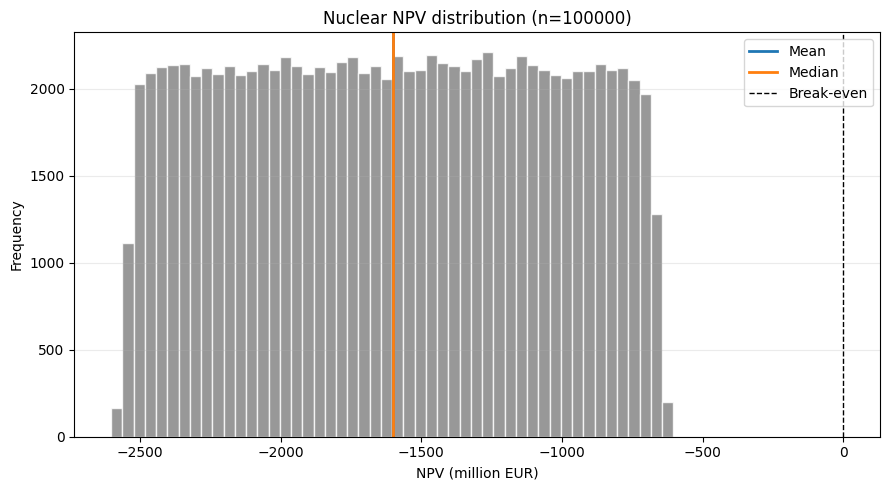

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


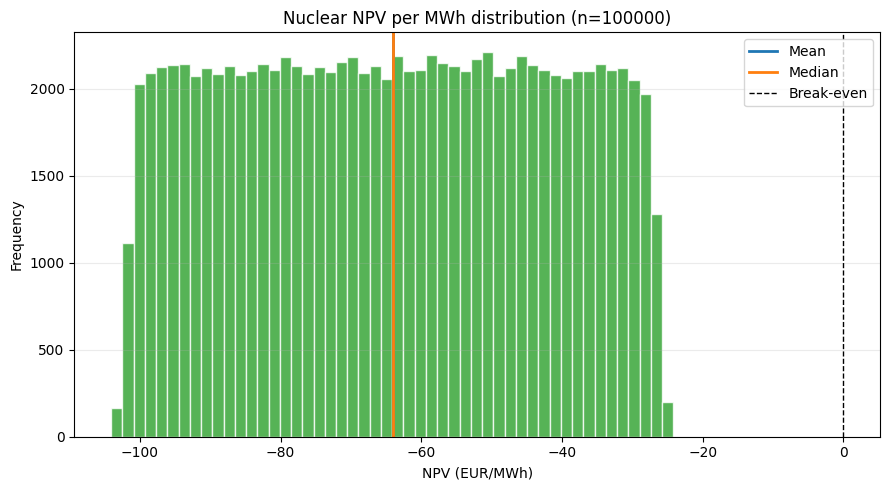

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        19.496796
annual_variable_opex_eur      7.230404
annual_fuel_cost_eur         22.880993
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     44.461807
Name: Mean annual value, million EUR, dtype: float64